# Part 1: Data Preparation and Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("exchange_rate.csv")

In [3]:
df_raw.columns

Index(['date', 'Ex_rate'], dtype='object')

In [4]:
date_col = df_raw.columns[0]

In [5]:
df = pd.read_csv("exchange_rate.csv", parse_dates=[date_col])
df.set_index(date_col, inplace=True)


In [6]:
df.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


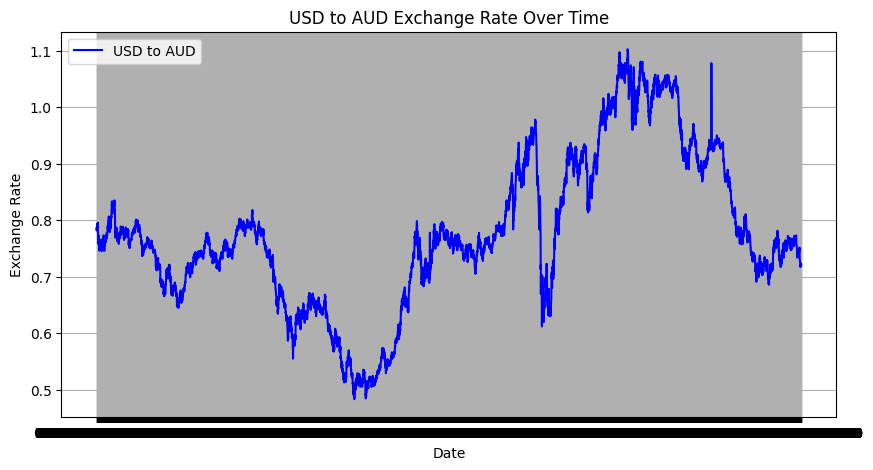

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df.iloc[:, 0], label='USD to AUD', color='blue')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df.isnull().sum()

Ex_rate    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2258)

In [11]:
df.drop_duplicates()

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
01-10-2010 00:00,0.717618
02-10-2010 00:00,0.719114
04-10-2010 00:00,0.719735


In [12]:
 df.index.duplicated().sum()

np.int64(0)

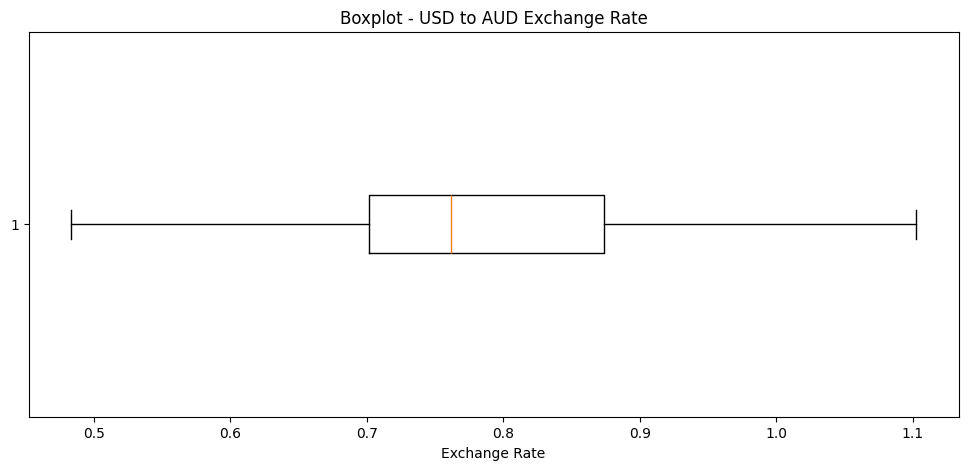

In [13]:
plt.figure(figsize=(12,5))
plt.boxplot(df.iloc[:, 0], vert=False)
plt.title('Boxplot - USD to AUD Exchange Rate')
plt.xlabel('Exchange Rate')
plt.show()

# part 2: Model Building-ARIMA

In [14]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [15]:
ts = df.iloc[:, 0]

In [16]:
adf_result = adfuller(ts)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary, differencing required")

ADF Statistic: -1.6649941807381365
p-value: 0.4492327353597987
Series is non-stationary, differencing required


In [18]:
ts_diff = ts.diff().dropna() if adf_result[1] >= 0.05 else ts

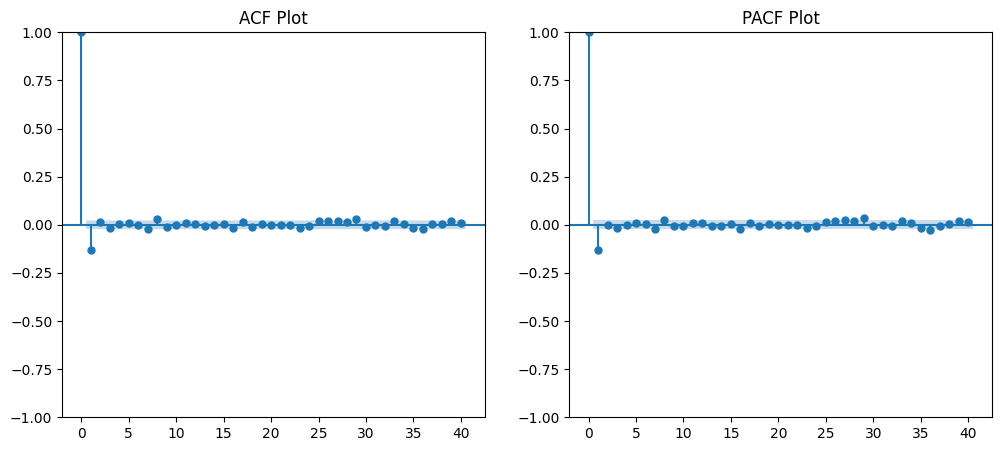

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(ts_diff, lags=40, ax=plt.gca())
plt.title("ACF Plot")

plt.subplot(1,2,2)
plot_pacf(ts_diff, lags=40, ax=plt.gca(), method='ywm')
plt.title("PACF Plot")
plt.show()

In [20]:
p = 1
d = 1 if adf_result[1] >= 0.05 else 0
q = 1

In [21]:
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sat, 15 Nov 2025   AIC                         -56102.322
Time:                        00:43:29   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py)

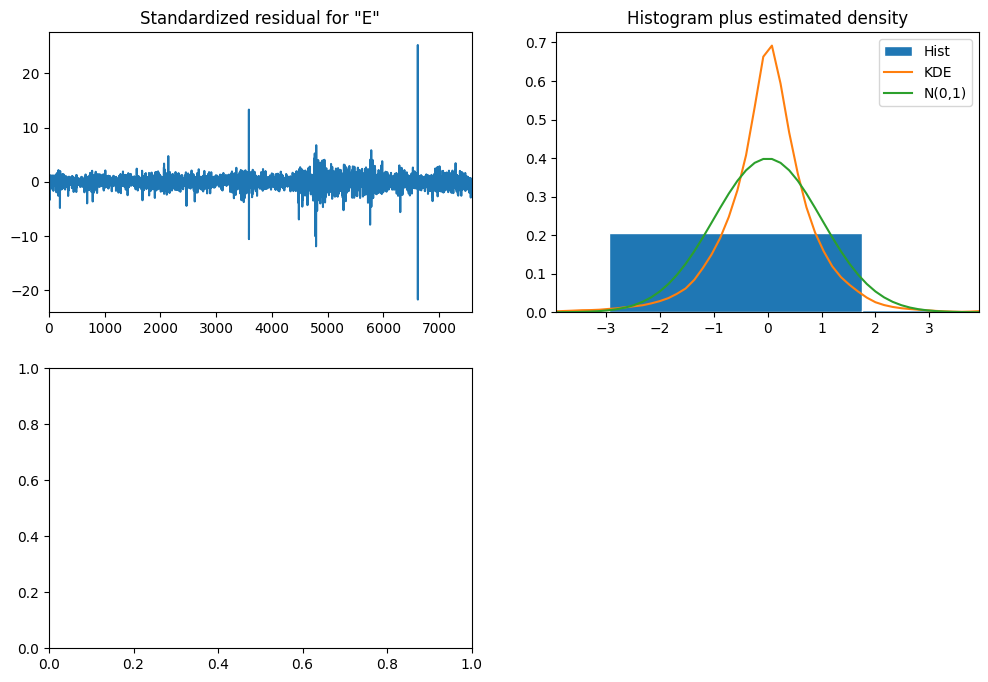

In [22]:
model_fit.plot_diagnostics(figsize=(12,8))
plt.show()

In [23]:
ts.index = pd.to_datetime(ts.index,dayfirst=True)
print(ts.index[:5])

DatetimeIndex(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04',
               '1990-01-05'],
              dtype='datetime64[ns]', name='date', freq=None)


In [24]:
# forecasting for 30 days
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=ts.index[-1]+pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

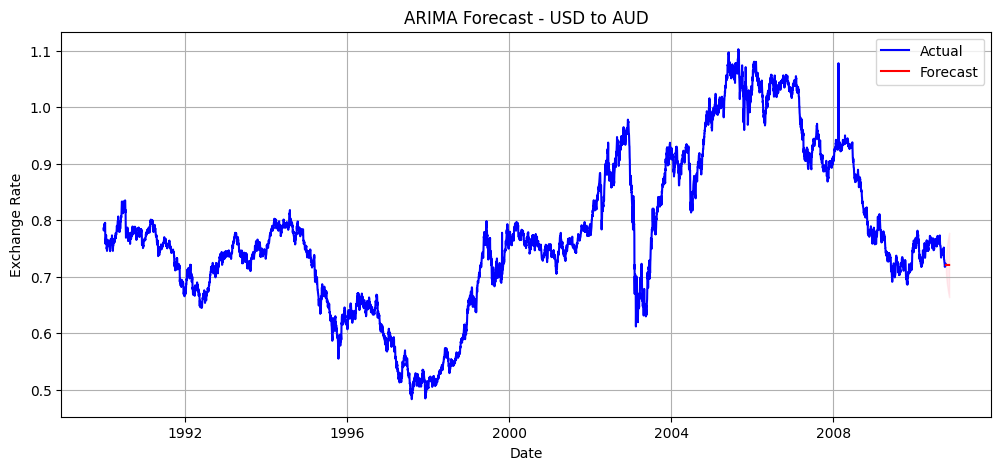

In [25]:
plt.figure(figsize=(12,5))
plt.plot(ts, label='Actual', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title('ARIMA Forecast - USD to AUD')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()